In [77]:
import pandas as pd
import numpy as np
import xarray as xr

In [78]:
naq_grid = np.fromfile(f'D:/workdata/38_2016-2020naqpms/wrfd01.dat',dtype= '>f4')
naq_grid = naq_grid.reshape((84,180,360))
naq_tap_heiz = naq_grid[60:80,126,126]
naq_uta_heiz = naq_grid[60:80,129,246]

In [79]:
#利用sys模块，获取脚本传入的参数
ct = xr.open_dataset(r'D:/workdata/42_10yr_naqpms/CT2022.molefrac_glb3x2_2018-01-01.nc',mode='r')

In [80]:
ct_tap_heiz = ct['gph'][0,:,63,102]
ct_uta_heiz = ct['gph'][0,:,64,22]

In [81]:
col_name_naq = ['time', 'col01', 'col02','col03','col04','col05','col06','col07','col08','col09','col10','col11','col12','col13','col14','col15','col16','col17','col18','col19','col20',]
col_name_ct  = ['time', 'col01', 'col02','col03','col04','col05','col06','col07','col08','col09','col10','col11','col12','col13','col14','col15','col16','col17','col18','col19','col20',\
                'col21', 'col22','col23','col24','col25','col26','col27','col28','col29','col30','col31','col32','col33','col34']
tap_conc_naq_df = pd.read_csv(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\NOAA GML 站点 NAQ CT数据\tap_conc_naq_hour.csv',header=None, names=col_name_naq)
tap_conc_ct_df  = pd.read_csv(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\NOAA GML 站点 NAQ CT数据\tap_station_conc_ct_3hour.csv',header=None, names=col_name_ct)
uta_conc_naq_df = pd.read_csv(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\NOAA GML 站点 NAQ CT数据\uta_conc_naq_hour.csv',header=None, names=col_name_naq)
uta_conc_ct_df  = pd.read_csv(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\NOAA GML 站点 NAQ CT数据\uta_station_conc_ct_3hour.csv',header=None, names=col_name_ct)

In [82]:
# 确保时间列的格式正确，这里假设时间列名称为 'Station'，需要转换为 datetime 格式
tap_conc_naq_df['time'] = pd.to_datetime(tap_conc_naq_df['time'], format='%Y%m%d%H')
tap_conc_ct_df['time'] = pd.to_datetime(tap_conc_ct_df['time'], format='%Y%m%d%H')
uta_conc_naq_df['time'] = pd.to_datetime(uta_conc_naq_df['time'], format='%Y%m%d%H')
uta_conc_ct_df['time'] = pd.to_datetime(uta_conc_ct_df['time'], format='%Y%m%d%H')
# 按月份进行分割并存储到字典中
#tap_conc_naq_monthly_data = {str(month): data for month, data in tap_conc_naq_df.groupby(tap_conc_naq_df['time'].dt.to_period('M'))}
#tap_conc_ct_monthly_data = {str(month): data for month, data in tap_conc_ct_df.groupby(tap_conc_ct_df['time'].dt.to_period('M'))}
#uta_conc_naq_monthly_data = {str(month): data for month, data in uta_conc_naq_df.groupby(uta_conc_naq_df['time'].dt.to_period('M'))}
#uta_conc_ct_monthly_data = {str(month): data for month, data in uta_conc_ct_df.groupby(uta_conc_ct_df['time'].dt.to_period('M'))}

In [83]:
def gethour(df):
    df.columns = ['time'] + [f'col{i+1}' for i in range(len(df.columns)-1)]

    # 将时间列转换为日期时间格式
    df['time'] = pd.to_datetime(df['time'], format='%Y%m%d%H')

    # 提取小时作为新的列
    df['hour'] = df['time'].dt.hour

    # 按小时分组并计算每个小时的均值
    hourly_avg = df.groupby('hour').mean()
    return hourly_avg

In [84]:
tap_conc_naq_hour = gethour(tap_conc_naq_df)
tap_conc_ct_hour = gethour(tap_conc_ct_df)
uta_conc_naq_hour = gethour(uta_conc_naq_df)
uta_conc_ct_hour = gethour(uta_conc_ct_df)

In [85]:
from pylab import *
from matplotlib.ticker import  MultipleLocator
from matplotlib.ticker import  FormatStrFormatter

In [86]:
#横轴
#xx3h = np.arange(6*24,99*24,3)+1  #ct
xxn = np.arange(12)+1 #naq,obs
xxnh = np.arange(20)+1 #naq,obs
xxch = np.arange(30)+1 

In [87]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker



In [88]:
import matplotlib.patches as mpatches  # 导入 matplotlib.patches 模块

In [90]:
# 填充前面的空白

data_to_fill = np.zeros((9,34))
data_to_fill[0:8,:] = tap_conc_ct_hour
data_to_fill[8,:] = tap_conc_ct_hour.values[0,:]

In [91]:

data_to_fill2 = np.zeros((9,34))
data_to_fill2[0:8,:] = uta_conc_ct_hour
data_to_fill2[8,:] = uta_conc_ct_hour.values[0,:]

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_10160\798652426.py:47: UserWarning: The following kwargs were not used by contour: 'label'
  c0 = ax[0][1].contourf(xv, naq_tap_heiz / 1000- naq_tap_heiz[0] / 1000, tap_conc_naq_hour.iloc[:, :20].T /1000, label='NAQPMS')
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_10160\798652426.py:81: UserWarning: The following kwargs were not used by contour: 'label'
  c2 = ax[1][1].contourf(xv, naq_uta_heiz / 1000 - naq_uta_heiz[0] / 1000, uta_conc_naq_hour.iloc[:, :20].T / 1000, label='NAQPMS')


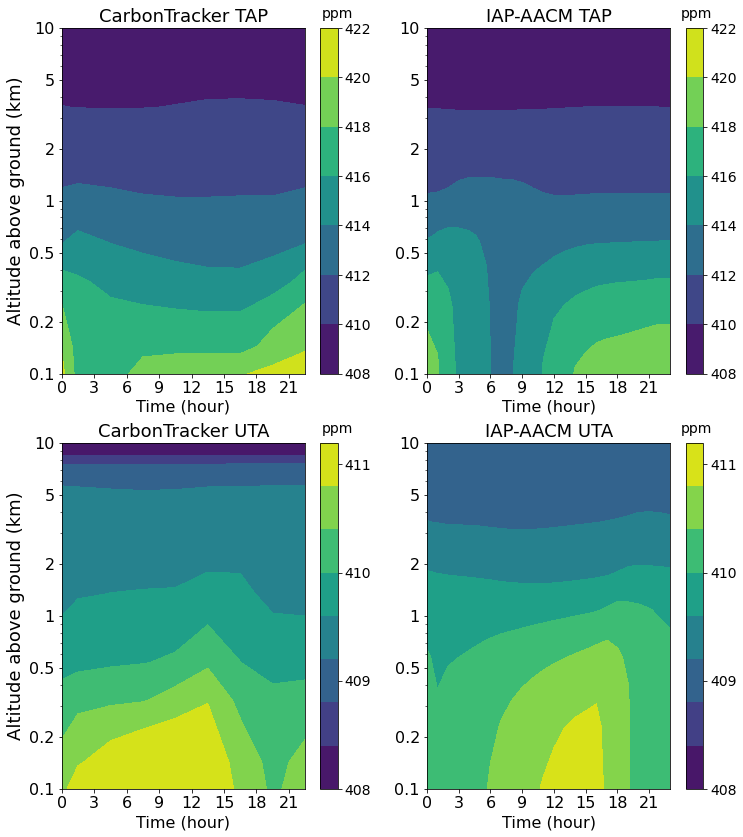

In [93]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 创建子图
fig, ax = plt.subplots(2, 2, figsize=(12, 14))

y_min_value = 0
y_max_value = 15

variables = ('00','01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','21','22','23')
xv = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])
variables = ('00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23')
xv2 = np.array([0,1.5, 4.5, 7.5, 10.5, 13.5, 16.5, 19.5, 22.5])

# 定义红色和蓝色
start_color = np.array([0, 0, 1])  # 红色 (RGB)
end_color = np.array([1, 0, 0])  # 蓝色 (RGB)

# 创建渐变色的列表
n_colors = 7  # 你希望的颜色数量
colors = [mcolors.to_hex(start_color + (end_color - start_color) * i / (n_colors - 1)) for i in range(n_colors)]

data_to_fill[data_to_fill <= 408] = 408
data_to_fill[data_to_fill >= 422] = 422
# 绘制 CarbonTracker TAP
c1 = ax[0][0].contourf(xv2, ct_tap_heiz[:34] / 1000 - ct_tap_heiz[0] / 1000, data_to_fill.T)
ax[0][0].set_title('CarbonTracker TAP', fontsize=18)
ax[0][0].tick_params(axis='both', labelsize=16)
ax[0][0].set_xlabel('Time (hour)', fontsize=16)  # 添加横坐标标签
ax[0][0].set_ylabel('Altitude above ground (km)', fontsize=18)  # 添加纵坐标标签
#ax[1].set_ylabel('altitude above ground', fontsize=12)  # 添加纵坐标标签
ax[0][0].set_ylim(y_min_value, y_max_value)
ax[0][0].set_xticks(np.arange(0, 24, 3))  # 设置横坐标刻度间隔为3小时


# 添加 colorbar，并设置标签
c1_cb = fig.colorbar(c1, ax=ax[0][0], orientation='vertical')
#c1_cb.set_label('Value (ppm)', fontsize=12, labelpad=10)
c1_cb.ax.xaxis.set_label_position('top')  # 将 colorbar 标签移至顶部
c1_cb.ax.xaxis.set_ticks_position('top')  # 设置 colorbar 刻度在顶部

# 绘制 NAQPMS TAP
var1 = tap_conc_naq_hour.iloc[:, :20].T /1000+3
var1[var1>=422] = 422
var1[var1<=408] = 408
c0 = ax[0][1].contourf(xv, naq_tap_heiz / 1000- naq_tap_heiz[0] / 1000, tap_conc_naq_hour.iloc[:, :20].T /1000, label='NAQPMS')
ax[0][1].set_title('IAP-AACM TAP', fontsize=18)
ax[0][1].tick_params(axis='both', labelsize=16)
ax[0][1].set_xlabel('Time (hour)', fontsize=16)  # 添加横坐标标签
ax[0][1].set_ylim(y_min_value, y_max_value)
ax[0][1].set_xticks(np.arange(0, 24, 3))  # 设置横坐标刻度间隔为3小时

# 添加 colorbar，并设置标签
data_to_fill[data_to_fill>=422] = 422
data_to_fill[data_to_fill<=408] = 408
c0_cb = fig.colorbar(c0, ax=ax[0][1], orientation='vertical', extend='both')
#c0_cb.set_label('Value (ppm)', fontsize=12, labelpad=10)
c0_cb.ax.xaxis.set_label_position('top')  # 将 colorbar 标签移至顶部
c0_cb.ax.xaxis.set_ticks_position('top')  # 设置 colorbar 刻度在顶部

data_to_fill2[data_to_fill2>=411.2] = 411.2
data_to_fill2[data_to_fill2<=408] = 408
# 绘制 CarbonTracker UTA
c3 = ax[1][0].contourf(xv2, ct_uta_heiz[:34] / 1000 - ct_uta_heiz[0] / 1000, data_to_fill2.T)
ax[1][0].set_title('CarbonTracker UTA', fontsize=18)
ax[1][0].tick_params(axis='both', labelsize=16)
ax[1][0].set_xlabel('Time (hour)', fontsize=16)  # 添加横坐标标签
ax[1][0].set_ylabel('Altitude above ground (km)', fontsize=18)  # 添加纵坐标标签
#ax[3].set_ylabel('altitude above ground', fontsize=12)  # 添加纵坐标标签
ax[1][0].set_ylim(y_min_value, y_max_value)
ax[1][0].set_xticks(np.arange(0, 24, 3))  # 设置横坐标刻度间隔为3小时

# 添加 colorbar，并设置标签
c3_cb = fig.colorbar(c3, ax=ax[1][0], orientation='vertical')
#c3_cb.set_label('Value (ppm)', fontsize=12, labelpad=10)
c3_cb.ax.xaxis.set_label_position('top')  # 将 colorbar 标签移至顶部
c3_cb.ax.xaxis.set_ticks_position('top')  # 设置 colorbar 刻度在顶部

# 绘制 NAQPMS UTA
c2 = ax[1][1].contourf(xv, naq_uta_heiz / 1000 - naq_uta_heiz[0] / 1000, uta_conc_naq_hour.iloc[:, :20].T / 1000, label='NAQPMS')
ax[1][1].set_title('IAP-AACM UTA', fontsize=18)
ax[1][1].tick_params(axis='both', labelsize=16)
ax[1][1].set_xlabel('Time (hour)', fontsize=16)  # 添加横坐标标签
#ax[2].set_ylabel('altitude above ground', fontsize=12)  # 添加纵坐标标签
ax[1][1].set_ylim(y_min_value, y_max_value)
ax[1][1].set_xticks(np.arange(0, 24, 3))  # 设置横坐标刻度间隔为3小时

# 添加 colorbar，并设置标签
c2_cb = fig.colorbar(c2, ax=ax[1][1], orientation='vertical')
#c2_cb.set_label('Value (ppm)', fontsize=12, labelpad=10)
c2_cb.ax.xaxis.set_label_position('top')  # 将 colorbar 标签移至顶部
c2_cb.ax.xaxis.set_ticks_position('top')  # 设置 colorbar 刻度在顶部



c0_cb.locator = MaxNLocator(integer=True)
c0_cb.update_ticks()

c1_cb.locator = MaxNLocator(integer=True)
c1_cb.update_ticks()

c2_cb.locator = MaxNLocator(integer=True)
c2_cb.update_ticks()

c3_cb.locator = MaxNLocator(integer=True)
c3_cb.update_ticks()


ax[0][0].text(24,11.4,'ppm',fontsize=14)
ax[0][1].text(24,11.4,'ppm',fontsize=14)
ax[1][0].text(24,11.4,'ppm',fontsize=14)
ax[1][1].text(24,11.4,'ppm',fontsize=14)


c0_cb.ax.tick_params(labelsize=14)
c1_cb.ax.tick_params(labelsize=14)
c2_cb.ax.tick_params(labelsize=14)
c3_cb.ax.tick_params(labelsize=14)


ax[0][0].set_ylim(0.1, 10)  # 设置对数坐标的显示范围为 0.01 km 到 10 km
ax[0][0].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
ax[0][0].set_yscale('log')
ax[0][1].set_ylim(0.1, 10)  # 设置对数坐标的显示范围为 0.01 km 到 10 km
ax[0][1].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
ax[0][1].set_yscale('log')
ax[1][0].set_ylim(0.1, 10)  # 设置对数坐标的显示范围为 0.01 km 到 10 km
ax[1][0].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
ax[1][0].set_yscale('log')
ax[1][1].set_ylim(0.1, 10)  # 设置对数坐标的显示范围为 0.01 km 到 10 km
ax[1][1].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
ax[1][1].set_yscale('log')

yticks_positions = [0.1, 0.2, 0.5, 1, 2, 5,10]
yticks_labels = ['0.1', '0.2', '0.5', '1', '2', '5','10' ]
ax[0][0].set_yticks(yticks_positions)
ax[0][0].set_yticklabels(yticks_labels, fontsize=16)
ax[0][1].set_yticks(yticks_positions)
ax[0][1].set_yticklabels(yticks_labels, fontsize=16)
ax[1][0].set_yticks(yticks_positions)
ax[1][0].set_yticklabels(yticks_labels, fontsize=16)
ax[1][1].set_yticks(yticks_positions)
ax[1][1].set_yticklabels(yticks_labels, fontsize=16)


# 图像分辨率
plt.rcParams['savefig.dpi'] = 500

plt.savefig(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\论文用图v5\iapaacm_tap_uta.contourf.r4.hour.v3.png', bbox_inches='tight')
